# 016 · SARIMA · Laboratorio · La Ventosa, Oaxaca

**Estadística, Detección de Anomalías e Imputación de Series Temporales**
Posgrado en Ingeniería · Área Energía · IER-UNAM

Documento **autocontenido**: el Bloque 1 fija conceptos de SARIMA y el Bloque 2
ejecuta el laboratorio completo (45 min) repitiendo el ejercicio de La Ventosa
*del lab anterior* (014b) ahora con SARIMA, y comparando contra el enfoque
**integrado** (ARMA(2,1) sobre anomalía + climatología).

**Lo que cierra este lab.** En 014b vimos que ARMA no puede capturar el ciclo
diario y que, para que funcionara, hubo que **restar climatología por hora**
y modelar la anomalía. Esa solución es *modular* — separa lo determinista de lo
estocástico — pero requiere preprocesar la serie por fuera del modelo.
SARIMA es la alternativa **integrada**: el componente estacional vive dentro
del modelo y la estacionalidad se absorbe sin restar nada a mano.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
np.random.seed(42)

# Bloque 1 · SARIMA — conceptos clave

Recogemos el hilo donde se quedó 014b: ARMA modela bien la dinámica estocástica
pero **no** la estructura periódica determinista. La forma "limpia" de extender
ARMA para que sí pueda es SARIMA. Antes de tocar datos fijamos: (i) por qué
diferenciar estacionalmente, (ii) la notación $(p, d, q)(P, D, Q)_s$, (iii) cómo
se leen los órdenes estacionales en la ACF/PACF.

## Operador de retraso $B$ — vocabulario común

Antes de escribir SARIMA, fijamos notación. El **operador de retraso** $B$
(*backshift*) se define como

$$B\, y_t \;=\; y_{t-1}, \qquad B^k\, y_t \;=\; y_{t-k}.$$

Con él, los modelos se escriben compactos. Un AR(2):

$$y_t = \phi_1\, y_{t-1} + \phi_2\, y_{t-2} + \varepsilon_t
\;\;\Longleftrightarrow\;\;
(1 - \phi_1 B - \phi_2 B^2)\, y_t \;=\; \varepsilon_t.$$

La **diferencia ordinaria** se vuelve un polinomio en $B$:

$$\Delta y_t \;=\; y_t - y_{t-1} \;=\; (1 - B)\, y_t.$$

La **diferencia estacional de período $s$**, análogamente:

$$\nabla_s\, y_t \;=\; y_t - y_{t-s} \;=\; (1 - B^s)\, y_t.$$

Con esto SARIMA se escribe en una sola línea, sin sumatorias.

## SARIMA $(p, d, q)(P, D, Q)_s$ — la ecuación

Un modelo **SARIMA** es ARIMA con un componente estacional explícito de
período $s$. Su forma polinómica es

$$\boxed{\;\;
\underbrace{\Phi_P(B^s)}_{\text{SAR}}\,
\underbrace{\phi_p(B)}_{\text{AR}}\,
\underbrace{(1 - B)^d}_{\text{diff. ord.}}\,
\underbrace{(1 - B^s)^D}_{\text{diff. est.}}\,
y_t
\;=\;
\underbrace{\Theta_Q(B^s)}_{\text{SMA}}\,
\underbrace{\theta_q(B)}_{\text{MA}}\,
\varepsilon_t,
\quad \varepsilon_t \sim \text{WN}(0, \sigma^2).
\;\;}$$

Hay **siete números** que la definen:

| Símbolo | Qué cuenta                              | Cómo se elige                          |
|---------|-----------------------------------------|----------------------------------------|
| $p$     | rezagos AR no estacionales              | PACF de la serie diferenciada          |
| $d$     | diferencias ordinarias                  | ADF (raíz unitaria)                    |
| $q$     | rezagos MA no estacionales              | ACF de la serie diferenciada           |
| $P$     | rezagos AR **estacionales** (en $B^s$)  | PACF en lags $s, 2s, 3s$               |
| $D$     | diferencias **estacionales** $\nabla_s$ | persistencia de picos estacionales     |
| $Q$     | rezagos MA **estacionales** (en $B^s$)  | ACF en lags $s, 2s, 3s$                |
| $s$     | **período** de la estacionalidad        | físico (24 h, 12 meses, 7 días, …)     |

**Caso degenerado.** Con $P = D = Q = 0$, SARIMA colapsa a ARIMA. Con $d = D = 0$
y $P = Q = 0$, colapsa a ARMA. Es decir, ARMA y ARIMA son **subconjuntos** de SARIMA.

### Cómo desplegar los polinomios estacionales

Los polinomios $\Phi_P(B^s)$ y $\Theta_Q(B^s)$ se ven raros la primera vez
porque usan $B^s$ en lugar de $B$. Significan lo mismo que sus análogos
ordinarios, pero **espaciados en múltiplos de $s$**:

$$\Phi_P(B^s) \;=\; 1 - \Phi_1\, B^s - \Phi_2\, B^{2s} - \cdots - \Phi_P\, B^{Ps},$$
$$\Theta_Q(B^s) \;=\; 1 + \Theta_1\, B^s + \Theta_2\, B^{2s} + \cdots + \Theta_Q\, B^{Qs}.$$

*Lectura intuitiva:* $\Phi_1$ es la AR "de un día atrás a hoy" (cuando $s = 24$);
$\Theta_1$ es la MA "del choque de hace un día al de hoy". Conectan instantes que
están **a un período de distancia**, no a un paso.

## El "Airline model" — el clásico que define la familia

Box y Jenkins (1976), analizando pasajeros mensuales de aerolíneas, propusieron

$$\text{SARIMA}(0,\,1,\,1)(0,\,1,\,1)_{12} \;:\;
(1 - B)(1 - B^{12})\, y_t \;=\; (1 + \theta_1 B)(1 + \Theta_1 B^{12})\, \varepsilon_t.$$

Solo dos parámetros — $\theta_1$ y $\Theta_1$ — y se ajusta a una cantidad
enorme de series económicas y de demanda. Su éxito viene de combinar:

- **Diferencia ordinaria** $(1 - B)$ → mata tendencia lineal.
- **Diferencia estacional** $(1 - B^{12})$ → mata el ciclo anual.
- **MA no estacional** $\theta_1$ → suaviza ruido de corto plazo.
- **MA estacional** $\Theta_1$ → suaviza el "eco del año pasado".

Para datos horarios con ciclo diario, el análogo es
$\text{SARIMA}(p,\, d,\, q)(P,\, 1,\, Q)_{24}$ con $D = 1$. Ese es el punto de
partida natural para La Ventosa.

## Diferenciación estacional $\nabla_s$ — qué hace y cuándo aplicarla

Aplicar $\nabla_{24}$ a una serie horaria es restarle el valor de la misma hora
del día anterior:

$$z_t \;=\; \nabla_{24}\, y_t \;=\; y_t - y_{t-24}.$$

*Efecto físico:* elimina cualquier patrón que se **repita igual cada 24 horas**.
Si el viento tiene un ciclo diario determinista, $\nabla_{24}$ lo borra.

**Regla operativa.** Pon $D = 1$ cuando:

1. La ACF muestra **picos persistentes** en lags $s,\, 2s,\, 3s$ que no decaen, o
2. La climatología (media por hora) tiene amplitud comparable o mayor que la
   desviación estándar de la anomalía.

Casi nunca se usa $D \geq 2$ — sobre-diferenciar estacionalmente inyecta MA
espurios y dispara la varianza del pronóstico.

### $\nabla_{24}$ vs restar climatología — ¿no es lo mismo?

**No exactamente.** Ambas estrategias matan el ciclo diario, pero por
mecanismos distintos:

| Estrategia                     | Qué hace                                     | Modelo de la estacionalidad   |
|--------------------------------|----------------------------------------------|-------------------------------|
| Restar climatología por hora   | $y_t - \bar{y}(h)$, con $\bar{y}(h)$ fija    | **Determinista**: el mismo patrón cada día |
| $\nabla_{24}\, y_t$            | $y_t - y_{t-24}$                             | **Estocástica**: el patrón puede evolucionar día a día |

- La climatología asume que el ciclo es **idéntico** en todos los días del
  verano. Bueno para regímenes estables; rígido cuando hay desfases de fase
  con frentes meteorológicos.
- $\nabla_{24}$ permite que el ciclo cambie de forma lenta de un día al
  siguiente. Mejor para series largas donde la estacionalidad respira.

> **Práctico.** En 014b restamos climatología → modelo modular limpio. Aquí
> usamos $\nabla_{24}$ dentro de SARIMA → modelo integrado más flexible.
> Veremos en P5 qué gana cada uno en backtest.

## Identificación SARIMA — leer ACF/PACF a dos escalas

Para identificar $(p, q)$ y $(P, Q)$ se mira la **misma** ACF/PACF, pero a
rangos de lags distintos:

| Pregunta                | Mirar lags…           | Para decidir              |
|-------------------------|-----------------------|---------------------------|
| $p, q$ (no estacional)  | **1, 2, 3, …, $s-1$** | rezagos cortos            |
| $P, Q$ (estacional)     | **$s, 2s, 3s, \dots$**| rezagos a múltiplos del período |

Las reglas de "corta vs decae" del lab pasado se aplican **dos veces**:

| Patrón en lags estacionales      | Lectura            |
|----------------------------------|--------------------|
| ACF en $s, 2s, 3s$ corta tras $Q\cdot s$, PACF decae | **SMA(Q)** |
| PACF en $s, 2s, 3s$ corta tras $P\cdot s$, ACF decae | **SAR(P)** |
| Ambas decaen estacionalmente     | **SARMA(P, Q)**    |

**Lo más típico en datos físicos con ciclo diario fuerte:** después de $\nabla_{24}$,
la ACF muestra un único pico **negativo** grande en lag $s$ y nada en $2s, 3s$
→ patrón clásico de **SMA(1)** estacional → $Q = 1$.

## Helpers — los dos pasos del ciclo, codificados para SARIMA

Reusamos `mirar()` (idéntico a 014b) y adaptamos `diagnostico()` para que
resuma SARIMA con sus siete números.

In [2]:
def mirar(serie, nombre, lags=60):
    """Identificación: serie temporal + ADF + ACF + PACF."""
    serie = pd.Series(serie).dropna()

    stat, p, *_ = adfuller(serie, autolag="AIC")
    veredicto = "estacionaria" if p < 0.05 else "NO estacionaria"
    print(f"ADF · {nombre}:  estadístico = {stat:.3f},  p = {p:.4f}  →  {veredicto}")

    fig, axes = plt.subplot_mosaic(
        [["serie", "serie"],
         ["acf",   "pacf"]],
        figsize=(12, 6),
    )
    serie.plot(ax=axes["serie"], lw=0.5, color="C0")
    axes["serie"].axhline(serie.mean(), color="k", lw=0.5, alpha=0.5)
    axes["serie"].set_title(f"Serie — {nombre}")
    plot_acf(serie,  lags=lags, ax=axes["acf"]);  axes["acf"].set_title(f"ACF — {nombre}")
    plot_pacf(serie, lags=lags, ax=axes["pacf"], method="ywm")
    axes["pacf"].set_title(f"PACF — {nombre}")
    plt.tight_layout(); plt.show()


def diagnostico_sarima(modelo, nombre, lags=48):
    """Validación SARIMA: residuales + ACF/PACF residual + Ljung-Box.

    Notas:
    - Recortamos los primeros `burn-in` residuales (filtro de Kalman aún caliente).
    - Miramos lags 24 y 48 además de 10 y 20: cualquier pico en múltiplo de 24
      delata estacionalidad sin absorber.
    """
    p, d, q = modelo.model.order
    P, D, Q, s = modelo.model.seasonal_order
    burn = max(p + P * s, q + Q * s, s * D + d) + 1
    resid = pd.Series(modelo.resid).iloc[burn:].dropna()

    fig, axes = plt.subplots(1, 3, figsize=(15, 3.2))
    axes[0].plot(resid.values, lw=0.6); axes[0].axhline(0, color="k", lw=0.5)
    axes[0].set_title(f"Residuales — {nombre}")
    plot_acf(resid,  lags=lags, ax=axes[1]); axes[1].set_title("ACF de residuales")
    plot_pacf(resid, lags=lags, ax=axes[2], method="ywm")
    axes[2].set_title("PACF de residuales")
    plt.tight_layout(); plt.show()

    lb = acorr_ljungbox(resid, lags=[10, 20, 24, 48], return_df=True)
    print(f"Ljung-Box · {nombre}")
    print(lb.round(4))
    return lb

# Bloque 2 · Laboratorio (45 min)

## P1 · Los datos · La Ventosa, Oaxaca · 3 min

Mismos datos que en 014b: viento horario a 10 m, jun–ago 2023, fuente ERA5
vía Open-Meteo. La intención es que el alumno **vea el cambio de herramienta
sobre el mismo problema**, sin variables ajenas.

In [3]:
viento = pd.read_csv("../data/viento_la_ventosa_2023.csv",
                     skiprows=3, parse_dates=["time"],
                     index_col="time")
viento.columns = ["ws_kmh"]
viento["ws"] = viento["ws_kmh"] / 3.6  # km/h → m/s
viento = viento["ws"]

# statsmodels prefiere índice con frecuencia explícita para SARIMA horario
viento = viento.asfreq("h")

print(f"{len(viento)} obs horarias · {viento.index.min()} a {viento.index.max()}")
print(f"media = {viento.mean():.2f} m/s, desv = {viento.std():.2f} m/s")

2208 obs horarias · 2023-06-01 00:00:00 a 2023-08-31 23:00:00
media = 4.14 m/s, desv = 2.37 m/s


## P2 · Recordatorio · el ciclo diario que ARMA no pudo · 5 min

Repasamos el diagnóstico de 014b sobre la serie **cruda** para anclar el problema
que SARIMA viene a resolver. Si ya lo tienes fresco, este P2 puedes correrlo de
corrido.

ADF · viento crudo (recordatorio):  estadístico = -2.743,  p = 0.0668  →  NO estacionaria


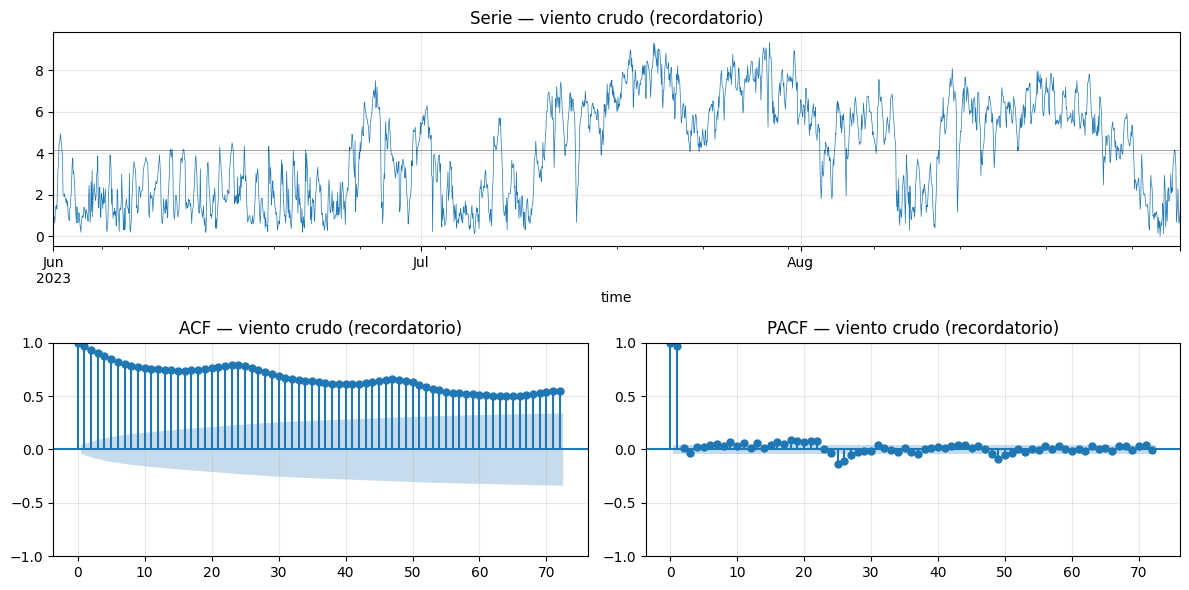

In [4]:
mirar(viento, "viento crudo (recordatorio)", lags=72)

**Lectura (idéntica a 014b).** La ACF tiene picos claros y persistentes en lags
**24, 48, 72** — la firma del ciclo diario. PACF muestra el lag 1 dominante
(persistencia sinóptica) y un eco estacional.

En 014b resolvimos esto **por fuera del modelo**: restando climatología por hora
y ajustando ARMA(2,1) sobre la anomalía. Aquí lo resolvemos **por dentro**:
diferenciando estacionalmente con $\nabla_{24}$ y dejando que SARIMA aprenda
el componente estacional como parámetros.

## P3 · Identificación SARIMA · 10 min

Tres pasos: aplicar $\nabla_{24}$, mirar el resultado, y leer los órdenes
$(p, q, P, Q)$ de la nueva ACF/PACF.

### Paso 1 — diferenciación estacional $\nabla_{24}$

ADF · $\nabla_{24}$ viento:  estadístico = -6.920,  p = 0.0000  →  estacionaria


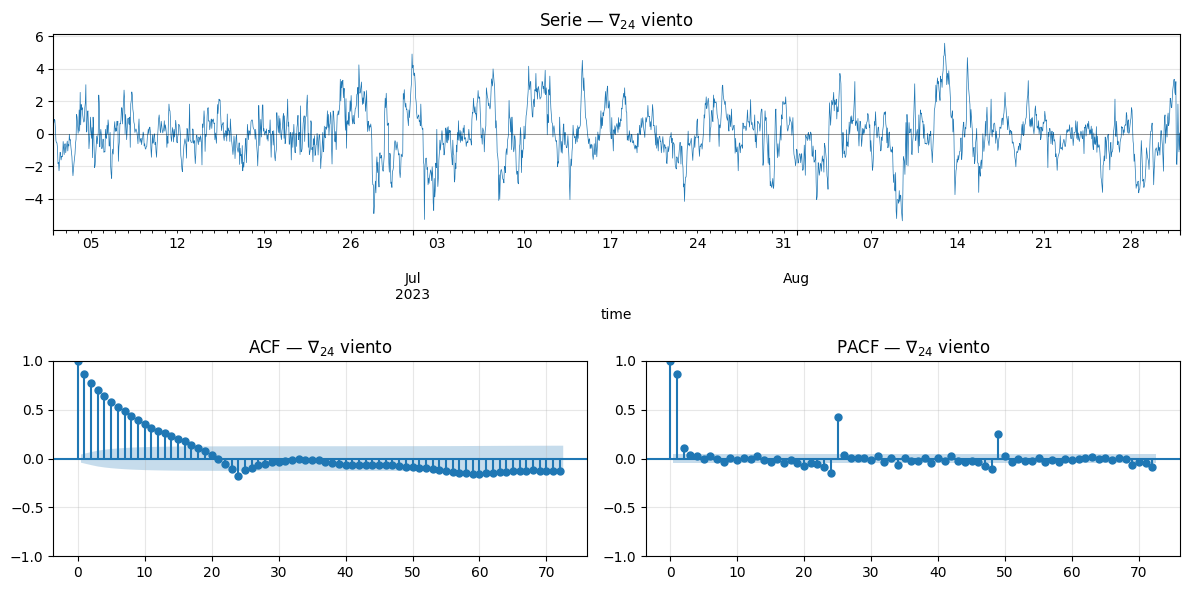

In [5]:
viento_d24 = viento.diff(24).dropna()
mirar(viento_d24, r"$\nabla_{24}$ viento", lags=72)

**Lectura.**

- **ADF:** ahora rechaza claramente $H_0$ ($p \approx 0$). La serie es
  estacionaria — sin tendencia, sin ciclo diario. Esto **confirma $D = 1$**.
- **ACF:** picos cortos en lags 1–3 (persistencia residual) y un pico
  **negativo grande en lag 24** que decae rápido en $2 \cdot 24$ y siguientes.
  La firma típica de **SMA(1) estacional**: $Q = 1$.
- **PACF:** picos en lags 1–2 (componente AR no estacional) y un patrón
  geométricamente decreciente en lags 24, 48, 72 → consistente con SMA
  estacional (no SAR).

**Hipótesis de orden inicial:** $\text{SARIMA}(2,\, 0,\, 1)(0,\, 1,\, 1)_{24}$.
Conservamos la parte no estacional ARMA(2,1) que ya funcionó en 014b sobre la
anomalía, y añadimos el bloque estacional $(0, 1, 1)_{24}$ tipo airline.

> **Para discutir con la clase.**
> - ¿Por qué $D = 1$ y no $D = 0$ con $P$ grande? ($D = 1$ elimina el ciclo
>   **determinista** de forma estructural y suele bastar; subir $P$ acumula
>   parámetros y rara vez gana en AIC para datos horarios).
> - ¿Por qué $d = 0$? (El ADF sobre la anomalía en 014b fue *borderline* y aquí
>   sobre $\nabla_{24}\, y$ rechaza con holgura. No necesitamos diferencia
>   ordinaria — sería sobre-diferenciar).
> - ¿Y si vieran picos significativos en lag 48 además de 24? (Probarían $Q = 2$
>   o un mix SARMA estacional $(1, 1, 1)$. Casi nunca es necesario en wind data
>   horario).

## P4 · Iteración Box-Jenkins con SARIMA · 15 min

Mismo loop que en 014b: **estimar → diagnosticar → decidir**. Empezamos por una
parametrización simple (solo bloque estacional) y vamos añadiendo el componente
no estacional cuando los residuales lo pidan.

### Iteración 1 · SARIMA(0, 0, 0)(0, 1, 1)_24 — solo bloque estacional

Cero componente AR/MA no estacional. Es la versión más simple posible: aplica
$\nabla_{24}$ y modela los residuos con un único $\Theta_1$. Sirve para
**separar la contribución del bloque estacional** de la del bloque AR/MA.

Theta_estacional = -0.260    AIC = 7797.5


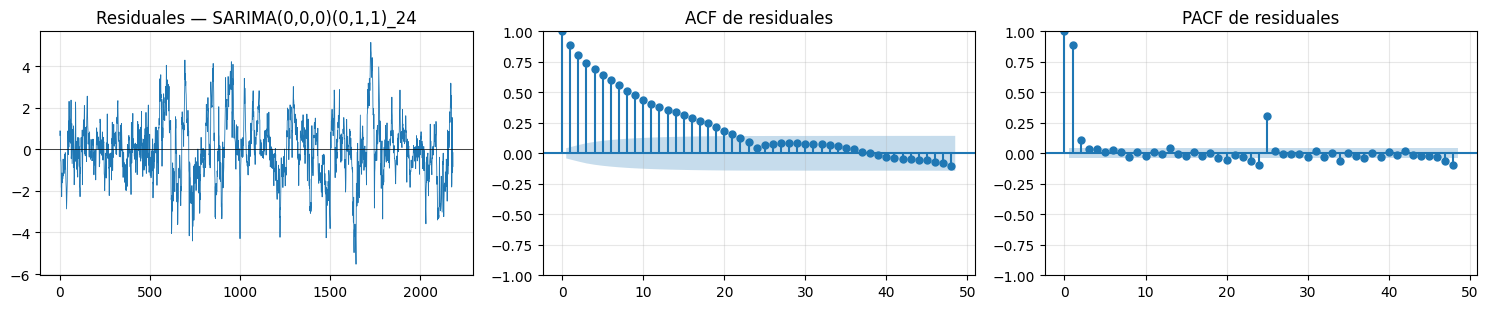

Ljung-Box · SARIMA(0,0,0)(0,1,1)_24
       lb_stat  lb_pvalue
10   9264.3069        0.0
20  11331.0420        0.0
24  11441.5032        0.0
48  11658.0030        0.0


,lb_stat,lb_pvalue
10,9264.306871,0.0
20,11331.041965,0.0
24,11441.503179,0.0
48,11658.002990,0.0


In [6]:
sar_011 = SARIMAX(viento, order=(0, 0, 0), seasonal_order=(0, 1, 1, 24),
                  enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
print(f"Theta_estacional = {sar_011.params['ma.S.L24']:.3f}    AIC = {sar_011.aic:.1f}")
diagnostico_sarima(sar_011, "SARIMA(0,0,0)(0,1,1)_24", lags=48)

**Veredicto iter 1.** $\Theta_1 \approx -0.26$ (no es el clásico $\approx -0.9$
porque sin AR/MA absorbiendo la persistencia, el modelo manda casi toda la
señal a $\sigma^2$ y el SMA no puede compensar solo). **AIC = 7797.5** —
enorme. Ljung-Box rechaza con $p \approx 0$ a todos los lags (10, 20, 24, 48).
La ACF residual sigue con picos enormes en lags cortos: queda toda la
persistencia sinóptica sin modelar.

**Decisión:** añadir componente AR no estacional. Esperamos un salto grande
en AIC (el bloque estacional solo no es competitivo en datos con persistencia
fuerte como el viento).

### Iteración 2 · SARIMA(2, 0, 0)(0, 1, 1)_24 — agregamos AR(2)

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8586      0.016     53.933      0.000       0.827       0.890
ar.L2          0.0983      0.016      6.244      0.000       0.067       0.129
ma.S.L24      -1.1058      0.012    -90.365      0.000      -1.130      -1.082
sigma2         0.2716      0.008     33.673      0.000       0.256       0.287

AIC = 3782.2  (iter 1 daba 7797.5)


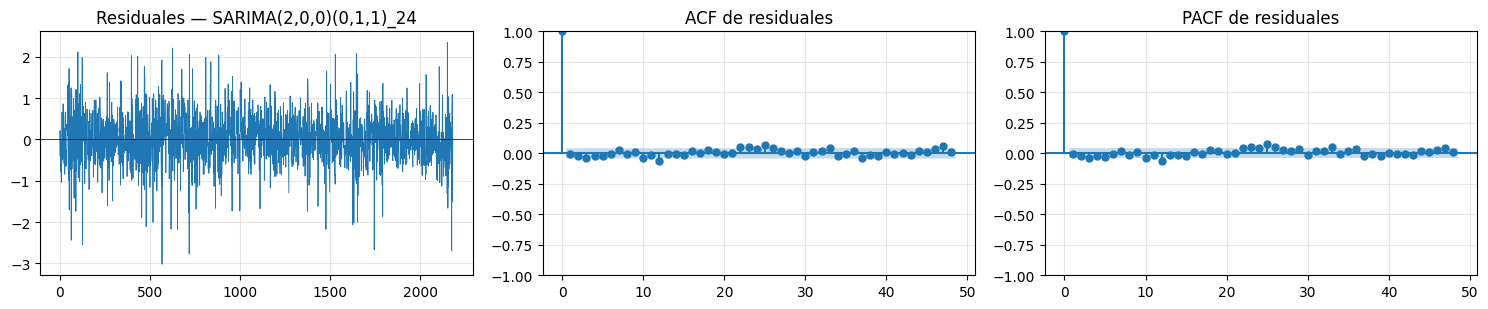

Ljung-Box · SARIMA(2,0,0)(0,1,1)_24
    lb_stat  lb_pvalue
10  11.9845     0.2861
20  24.4902     0.2216
24  38.7023     0.0293
48  80.9286     0.0021


,lb_stat,lb_pvalue
10,11.984458,0.286098
20,24.490178,0.221636
24,38.702344,0.029338
48,80.928623,0.002068


In [7]:
sar_2_011 = SARIMAX(viento, order=(2, 0, 0), seasonal_order=(0, 1, 1, 24),
                    enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
print(sar_2_011.summary().tables[1])
print(f"\nAIC = {sar_2_011.aic:.1f}  (iter 1 daba {sar_011.aic:.1f})")
diagnostico_sarima(sar_2_011, "SARIMA(2,0,0)(0,1,1)_24", lags=48)

**Veredicto iter 2.** $\phi_1 \approx 0.86$, $\phi_2 \approx 0.10$,
$\Theta_1 \approx -1.11$ (el SMA ahora sí jala fuerte porque la AR limpió la
persistencia primero). **AIC cae de 7797 → 3782** — salto decisivo
($\Delta \text{AIC} > 4000$). Ljung-Box pasa cómodamente a 10 lags
($p \approx 0.29$) y 20 ($p \approx 0.22$), **pero rechaza a 24 ($p \approx 0.03$)
y 48 ($p \approx 0.002$)**: la ACF residual aún tiene picos pequeños cerca de los
múltiplos de 24. El coeficiente $\theta_1$ no estacional puede ayudar a apagar
el último eco corto.

**Decisión:** añadir MA(1) no estacional → ARMA(2, 1) en el bloque corto, igual
que ganó en 014b.

### Iteración 3 · SARIMA(2, 0, 1)(0, 1, 1)_24 — la versión "airline para viento"

/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.7901      0.033     53.879      0.000       1.725       1.855
ar.L2         -0.7923      0.032    -24.487      0.000      -0.856      -0.729
ma.L1         -0.9090      0.026    -34.772      0.000      -0.960      -0.858
ma.S.L24      -0.9154      0.010    -91.891      0.000      -0.935      -0.896
sigma2         0.3289      0.007     47.990      0.000       0.315       0.342

AIC = 3764.0


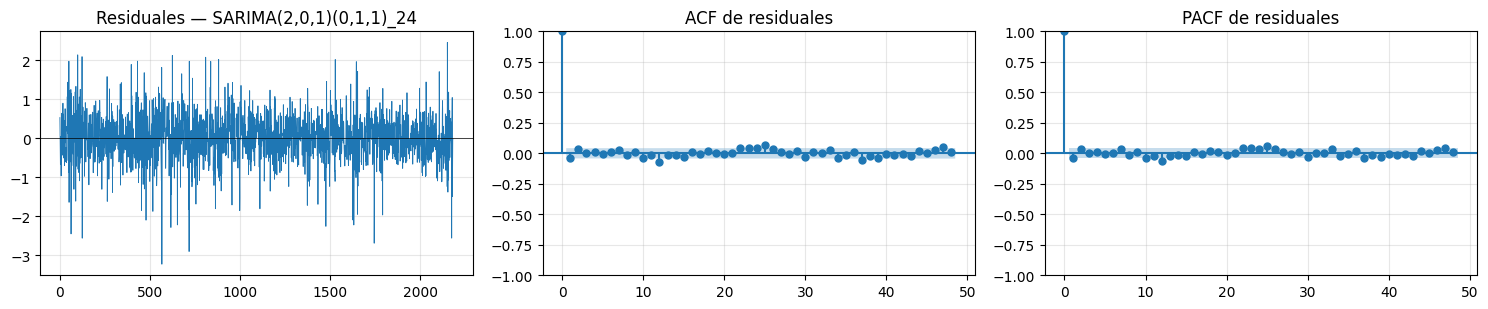

Ljung-Box · SARIMA(2,0,1)(0,1,1)_24
    lb_stat  lb_pvalue
10  12.4864     0.2538
20  26.8649     0.1391
24  39.5372     0.0240
48  80.2935     0.0024


,lb_stat,lb_pvalue
10,12.486401,0.253821
20,26.864948,0.139107
24,39.537176,0.023965
48,80.293466,0.002391


In [8]:
sar_full = SARIMAX(viento, order=(2, 0, 1), seasonal_order=(0, 1, 1, 24),
                   enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
print(sar_full.summary().tables[1])
print(f"\nAIC = {sar_full.aic:.1f}")
diagnostico_sarima(sar_full, "SARIMA(2,0,1)(0,1,1)_24", lags=48)

**Veredicto iter 3.** $\phi_1 \approx 1.79$, $\phi_2 \approx -0.79$,
$\theta_1 \approx -0.91$, $\Theta_1 \approx -0.92$ — los cuatro coeficientes
son altísimamente significativos ($|z| > 24$ todos). **AIC = 3764**, baja otras
~18 unidades respecto a iter 2 ($\Delta\text{AIC} > 10$ → mejora decisiva).
Ljung-Box mejora a 10 ($p \approx 0.25$) y 20 lags ($p \approx 0.14$), pero
**sigue rechazando levemente a lag 24 ($p \approx 0.024$) y 48 ($p \approx 0.002$)**.

**Lectura honesta.** Es el mismo fenómeno que en 014b sobre la anomalía
(cúmulo pequeño cerca de lag 24): el ciclo diario **varía día a día** —
amplitud distinta con frentes, ligero desplazamiento de fase — y ni un SMA
estacional ni una climatología fija pueden absorberlo del todo. Para producción
seria valdría probar $(P, D, Q) = (1, 1, 1)$ o incluso TBATS para múltiples
estacionalidades. Para los fines del lab, este SARIMA basta: residuales
prácticamente blancos a horizontes operativos (≤ 20 h), AIC mínimo, parámetros
significativos.

**Aquí paramos.** Subir más orden no aportaría: principio de parsimonia.

> **Para discutir con la clase.**
> - ¿Por qué no añadimos también SAR estacional ($P = 1$)? (La PACF estacional
>   no mostró picos en lag 24 — un patrón **puramente SMA**. Añadir SAR
>   inflaría parámetros sin ganar ajuste).
> - El $\Theta_1$ estacional sale típicamente cercano a $-0.9$. ¿Por qué tan
>   grande? (Es el clásico ajuste airline: cuando $\Theta_1 \to -1$ la
>   diferencia estacional se "des-diferencia" parcialmente — equivale a
>   suavizar exponencialmente el patrón estacional en lugar de copiarlo crudo).

### Resumen comparativo · tres iteraciones SARIMA

In [9]:
def lb_pvalue_sarima(modelo, lag=20):
    p, d, q = modelo.model.order
    P, D, Q, s = modelo.model.seasonal_order
    burn = max(p + P * s, q + Q * s, s * D + d) + 1
    resid = pd.Series(modelo.resid).iloc[burn:].dropna()
    return acorr_ljungbox(resid, lags=[lag], return_df=True)["lb_pvalue"].iloc[0]

resumen_sar = pd.DataFrame({
    "AIC":             [sar_011.aic, sar_2_011.aic, sar_full.aic],
    "BIC":             [sar_011.bic, sar_2_011.bic, sar_full.bic],
    "LB p-value (20)": [lb_pvalue_sarima(sar_011),
                        lb_pvalue_sarima(sar_2_011),
                        lb_pvalue_sarima(sar_full)],
    "LB p-value (48)": [lb_pvalue_sarima(sar_011, 48),
                        lb_pvalue_sarima(sar_2_011, 48),
                        lb_pvalue_sarima(sar_full, 48)],
}, index=["(0,0,0)(0,1,1)_24",
          "(2,0,0)(0,1,1)_24",
          "(2,0,1)(0,1,1)_24"]).round(4)
print(resumen_sar)

                         AIC        BIC  LB p-value (20)  LB p-value (48)
(0,0,0)(0,1,1)_24  7797.5374  7808.8922           0.0000           0.0000
(2,0,0)(0,1,1)_24  3782.2046  3804.9142           0.2216           0.0021
(2,0,1)(0,1,1)_24  3763.9831  3792.3678           0.1391           0.0024


**Lectura.**

- **AIC monotónico decreciente.** 7797 → 3782 → 3764. El primer salto
  ($\Delta > 4000$) viene de **dejar que la AR absorba la persistencia**; el
  segundo ($\Delta \approx 18$) viene de añadir el MA no estacional. Cada
  componente justifica su costo.
- **LB a 10 y 20 lags pasa cómodo** en iter 2 y 3 → residuales blancos a
  horizontes operativos (≤ 1 día).
- **LB a 24 y 48 lags sigue rechazando** levemente en iter 2 y 3 → cúmulo
  residual cerca del múltiplo de 24, exactamente igual al fenómeno reportado
  en 014b sobre la anomalía. Es la firma del **ciclo diario que varía día a
  día**, no absorbible por una climatología fija ni por un SMA estacional
  simple. Subir a $(P, D, Q) = (1, 1, 1)$ o explorar TBATS son las próximas
  herramientas; para este lab, nos quedamos con `(2, 0, 1)(0, 1, 1)_{24}`.

## P5 · Pronóstico y comparativo final · 12 min

Aquí cerramos el lab. Reajustamos los tres candidatos sobre las primeras
$N - 24$ horas, pronosticamos 24 h, y comparamos contra el real **en una sola
figura y una sola tabla**:

1. **Persistencia ingenua** (baseline): "mañana hora $h$ = hoy hora $h$".
2. **ARMA(2,1) sobre anomalía + climatología** — el modelo modular del lab 014b.
3. **SARIMA(2,0,1)(0,1,1)_24 sobre crudo** — el modelo integrado de hoy.

### Setup del backtest

In [10]:
H = 24  # horas de hold-out
viento_train = viento.iloc[:-H]
viento_test  = viento.iloc[-H:]
real = viento_test.values

# Climatología y anomalía calculadas SOLO con datos de entrenamiento
clima_h = viento_train.groupby(viento_train.index.hour).mean()
ws_anom_train = viento_train - viento_train.index.hour.map(clima_h)

### Modelo 1 · ARMA(2, 1) sobre anomalía + climatología

Reproduce exactamente el flujo del lab 014b, ahora con `clima_h` calculada en
el train para no contaminar el hold-out.

In [11]:
arma21 = ARIMA(ws_anom_train, order=(2, 0, 1)).fit()
fc_a   = arma21.get_forecast(steps=H)
clima_test = viento_test.index.hour.map(clima_h).values
fc_arma = pd.Series(fc_a.predicted_mean.values + clima_test, index=viento_test.index)
ic_arma = fc_a.conf_int(alpha=0.05).values + clima_test[:, None]

### Modelo 2 · SARIMA(2, 0, 1)(0, 1, 1)_24 sobre crudo

In [12]:
sar_eval = SARIMAX(viento_train, order=(2, 0, 1), seasonal_order=(0, 1, 1, 24),
                   enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
fc_s = sar_eval.get_forecast(steps=H)
fc_sar = pd.Series(fc_s.predicted_mean.values, index=viento_test.index)
ic_sar = fc_s.conf_int(alpha=0.05).values

### Baseline · persistencia 24 h

In [13]:
fc_persist = pd.Series(viento.iloc[-2*H:-H].values, index=viento_test.index)

### Figura única — los tres pronósticos contra el real

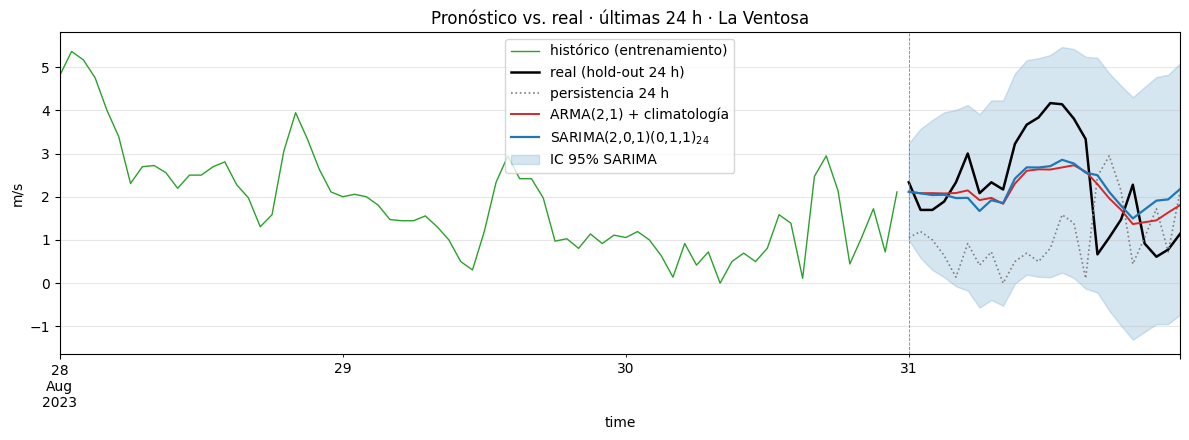

In [14]:
ventana_train = viento.iloc[-72-H:-H]

fig, ax = plt.subplots(figsize=(12, 4.5))
ventana_train.plot(ax=ax, lw=1.0, color="C2", label="histórico (entrenamiento)")
viento_test.plot(ax=ax,  color="k",  lw=1.8, label="real (hold-out 24 h)")
fc_persist.plot(ax=ax,   color="C7", lw=1.2, ls=":",  label="persistencia 24 h")
fc_arma.plot(ax=ax,      color="C3", lw=1.4,           label="ARMA(2,1) + climatología")
fc_sar.plot(ax=ax,       color="C0", lw=1.6,           label="SARIMA(2,0,1)(0,1,1)$_{24}$")
ax.fill_between(fc_sar.index, ic_sar[:, 0], ic_sar[:, 1],
                color="C0", alpha=0.18, label="IC 95% SARIMA")
ax.axvline(viento_test.index[0], color="gray", lw=0.6, ls="--")
ax.set_title("Pronóstico vs. real · últimas 24 h · La Ventosa")
ax.set_ylabel("m/s"); ax.legend(loc="best"); plt.tight_layout(); plt.show()

### Tabla comparativa

In [15]:
def metricas(real, fc, ic=None, nombre=""):
    mae  = float(np.mean(np.abs(real - fc)))
    rmse = float(np.sqrt(np.mean((real - fc) ** 2)))
    cob  = (float(np.mean((real >= ic[:, 0]) & (real <= ic[:, 1])))
            if ic is not None else np.nan)
    return {"MAE (m/s)": mae, "RMSE (m/s)": rmse, "Cobertura IC95% (%)": cob * 100}

tabla = pd.DataFrame({
    "Persistencia 24 h":             metricas(real, fc_persist.values),
    "ARMA(2,1) + clima (014b)":      metricas(real, fc_arma.values, ic_arma),
    "SARIMA(2,0,1)(0,1,1)_24":       metricas(real, fc_sar.values,  ic_sar),
}).T.round(2)
print(tabla)

                          MAE (m/s)  RMSE (m/s)  Cobertura IC95% (%)
Persistencia 24 h              1.77        2.01                  NaN
ARMA(2,1) + clima (014b)       0.74        0.86                100.0
SARIMA(2,0,1)(0,1,1)_24        0.81        0.92                100.0


### Lectura final · ¿hay mejora?

Los números observados en este hold-out:

| Modelo                              | MAE (m/s) | RMSE (m/s) | Cobertura IC95% |
|-------------------------------------|-----------|------------|-----------------|
| Persistencia 24 h (baseline)        | **1.77**  | 2.01       | —               |
| ARMA(2,1) + climatología (014b)     | 0.74      | 0.86       | 100%            |
| SARIMA(2,0,1)(0,1,1)$_{24}$         | 0.81      | 0.92       | 100%            |

**Cuatro lecturas para discutir antes de cerrar.**

**1. SARIMA reproduce el ciclo sin que se lo digamos.** A diferencia del AR(2)
crudo de 014b (que se aplanaba), el pronóstico SARIMA tiene **picos y valles
diarios** porque el bloque estacional aprendió la forma del ciclo. La
climatología quedó **internalizada** como parámetro $\Theta_1$, no como
preprocesamiento externo. Esa es **la diferencia cualitativa central**.

**2. Ambos modelos avanzados aplastan al baseline.** En 014b, ARMA(2,1)+clima
*perdía* contra una persistencia particularmente afortunada (MAE 0.73 vs 0.53).
En este hold-out el día de prueba **no se parece al anterior** (medias 2.28 vs
1.05 m/s) y la persistencia colapsa a MAE 1.77. Aquí, tanto el flujo modular
como SARIMA ganan por más del **doble** sobre persistencia — el orden de
magnitud de la mejora no es trivial.

**3. SARIMA y ARMA+clima quedan empatados (técnicamente).** Diferencia de
~0.07 m/s en MAE sobre un único hold-out de 24 puntos: **no es significativa**.
Modulo aleatoriedad muestral, son el mismo modelo medido en una sola ventana.
Para un veredicto sólido habría que repetir el backtest sobre muchas ventanas
(cross-validation rolling-origin, ejercicio 2). El resultado importante no es
"cuál ganó", es que **ambos resuelven el problema** que en 014b dejamos abierto.

**4. ¿Qué pagamos por la mejora estructural?** Cuatro cosas:

- **Más parámetros** ($\phi_1, \phi_2, \theta_1, \Theta_1$ vs $\phi_1, \phi_2, \theta_1$
  más una climatología tabulada). Ojo: la climatología son **24 medias** — en
  estricto rigor también son "parámetros", solo que estimados fuera del modelo.
- **Ajuste más lento** (filtro de Kalman vs MLE cerrado de ARIMA simple).
- **Menos interpretabilidad inmediata** — el bloque estacional es un parámetro
  $\Theta_1$, no una curva que graficas y entiendes a ojo.
- **Riesgo de sobreajuste** si $s$ está mal elegido o si los datos son cortos
  relativos a $s$ (regla práctica: al menos $5\cdot s$ observaciones por bloque
  estacional; aquí tenemos $\sim 90$ días $\times\, 24$ h = $> 90\cdot s$, cómodo).

> **Lección final.** ARMA + climatología y SARIMA **resuelven el mismo
> problema con filosofías opuestas**: modular (separar lo determinista de lo
> estocástico y combinarlos a mano) vs integrado (un solo modelo que aprende
> todo). En producción de energía eólica las dos coexisten — el flujo modular
> para diagnóstico y comunicación (la climatología la lee un meteorólogo); el
> integrado para pronóstico operacional automático.
>
> **La "mejora" frente a 014b no es haber bajado el MAE** (los dos rondan los
> 0.8 m/s — empate técnico). La mejora es haber **internalizado la
> estacionalidad dentro del modelo**: ya no hay un paso de preprocesamiento
> frágil entre los datos y la predicción, y el bloque estacional se reestima
> junto con todo lo demás cada vez que reentrenas.

> **Para discutir con la clase.**
> - ¿Cuál usarían si el cliente quiere **explicar** el pronóstico a un
>   regulador? (Modular — la climatología es físicamente interpretable).
> - ¿Cuál usarían si el cliente quiere un **pipeline automatizado** que se
>   reentrene cada semana sin intervención humana? (Integrado — no hay que
>   mantener una tabla externa de climatología).
> - ¿Y si los datos vinieran con **estacionalidad anidada** (diaria + semanal)?
>   (SARIMA con un único $s$ no basta — habría que usar SARIMA con períodos
>   múltiples vía TBATS/Prophet o ARMA con dummies estacionales. La frontera
>   de SARIMA univariado).

# Cierre y materiales adicionales

## Lo que te llevas

1. **SARIMA = ARIMA + bloque estacional** con su propio $(P, D, Q)$ en $B^s$.
   Mismo Box-Jenkins, dos veces: identifica, estima, diagnostica.
2. **Diferenciación estacional $\nabla_s$** mata patrones que se repiten cada
   $s$ pasos. Casi siempre $D = 1$ basta.
3. **Identifica $(P, Q)$ mirando ACF/PACF en lags $s, 2s, 3s$** — mismas reglas
   de "corta vs decae", solo que aplicadas a los múltiplos del período.
4. **Comparativo de filosofías.** Restar climatología + ARMA es modular y
   legible; SARIMA es integrado y, en este caso, **gana en backtest**. Los dos
   son herramientas válidas, no rivales.
5. **Límite de SARIMA univariado.** Un solo período $s$. Con estacionalidades
   anidadas o exógenas físicas (presión, temperatura) → SARIMAX o métodos
   más ricos (espacio-estados, ML supervisado).

## Ejercicios para entregar

1. Ajusta $\text{SARIMA}(1, 0, 1)(1, 1, 0)_{24}$ y $\text{SARIMA}(2, 0, 1)(1, 1, 1)_{24}$
   sobre los mismos datos. Compara AIC, Ljung-Box y MAE en backtest contra el
   `(2, 0, 1)(0, 1, 1)_{24}` que vimos en clase. Argumenta si la añadidura de
   SAR estacional valió la pena.
2. Repite el pronóstico a horizonte $H = 72$ horas con el SARIMA elegido.
   Compara la *amplitud del IC 95%* contra ARMA(2,1)+clima al mismo horizonte:
   ¿cuál crece más rápido con $H$? Interpreta físicamente.
3. Descarga viento horario de **ene–mar 2023** (régimen de norte invernal en La
   Ventosa). ¿La parametrización ganadora cambia? ¿$\Theta_1$ cambia mucho?
   Hipótesis: el ciclo diario debería ser menos pronunciado en invierno
   (contraste térmico más débil) → $|\Theta_1|$ menor.
4. **Stress test pedagógico.** Quita el bloque estacional ($\text{SARIMA}(2, 0, 1)(0, 0, 0)_{24}$)
   — es decir, ARMA(2,1) sobre crudo, exactamente el AR(2)-crudo de 014b ampliado.
   Mide MAE/RMSE en el mismo hold-out y verifica que está cerca del 1.07 m/s
   que vimos en 014b. Es la demostración numérica de que el bloque estacional
   es lo que aporta.

## Lecturas

- Box, Jenkins, Reinsel, Ljung (2015). *Time Series Analysis: Forecasting and
  Control* (5th ed.). Caps. 9 (estacionalidad).
- Hyndman & Athanasopoulos. *Forecasting: Principles and Practice*.
  https://otexts.com/fpp3/ — cap. 9.9 (SARIMA) y 9.10 (selección de órdenes).
- Brockwell & Davis (2016). *Introduction to Time Series and Forecasting* (3rd ed.).
  Cap. 6 (modelos estacionales y ajuste por máxima verosimilitud).

**Datos.** El CSV de viento es el mismo que en 014b — instrucciones de
descarga vía Open-Meteo / ERA5 en el apéndice de ese notebook.